In [5]:
# import sys, os
# from pathlib import Path
#
# def add_repo_path():
#     """
#     stock_forecast 프로젝트 루트를 자동 탐색하고,
#     해당 경로를 sys.path에 추가하여 import 오류를 방지합니다.
#     """
#     current = Path(__file__).resolve()
#     for parent in current.parents:
#         # DATA 폴더가 존재하는 경로를 찾으면 sys.path에 추가
#         if (parent / "DATA").exists():
#             sys.path.insert(0, str(parent))
#             print(f"[INFO] Project root added to sys.path: {parent}")
#             return str(parent)
#     # 만약 못 찾을 경우 대비 - fallback 경로 지정
#     fallback = r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast"
#     if os.path.isdir(fallback):
#         sys.path.insert(0, fallback)
#         print(f"[WARNING] Using fallback path: {fallback}")
#         return fallback
#     raise FileNotFoundError("❌ DATA 폴더를 찾을 수 없습니다.")
#
# # 경로 추가 실행
# project_root = add_repo_path()


import pandas as pd
import numpy as np
import FinanceDataReader as fdr
from datetime import datetime, timedelta
import requests
from DATA.stock_invest_function import get_db_host

def calculate_returns_and_volatility(df, price_column='Close'):
    """
    주가 데이터에 수익률과 변동성을 계산하여 추가하는 함수

    Parameters:
    -----------
    df : pandas.DataFrame
        주가 데이터 (Close 컬럼 포함)
    price_column : str
        가격 컬럼명 (기본값: 'Close')

    Returns:
    --------
    pandas.DataFrame
        수익률과 변동성이 추가된 데이터프레임
    """
    # 데이터 복사
    result_df = df.copy()

    # 일일 수익률 계산 (로그 수익률)
    result_df['Daily_Return'] = np.log(result_df[price_column] / result_df[price_column].shift(1))

    # 기간별 수익률 계산 (rolling)
    periods = {
        20: '20D',
        60: '60D',
        120: '120D',
        252: '252D'
    }

    for days, label in periods.items():
        # 누적 수익률 (기간 동안의 총 수익률)
        result_df[f'Return_{label}'] = result_df[price_column].pct_change(periods=days)

        # 변동성 (일일 수익률의 표준편차를 연율화)
        result_df[f'Volatility_{label}'] = result_df['Daily_Return'].rolling(window=days).std() * np.sqrt(252)

    return result_df


def calculate_beta(stock_df, market_df, periods=[252, 756, 1260]):
    """
    개별 주가의 베타를 계산하는 함수

    Parameters:
    -----------
    stock_df : pandas.DataFrame
        개별 주가 데이터 (Daily_Return 컬럼 포함)
    market_df : pandas.DataFrame
        시장 지수 데이터 (Daily_Return 컬럼 포함)
    periods : list
        베타 계산 기간 (기본값: [252, 756, 1260] = 1년, 3년, 5년)

    Returns:
    --------
    pandas.DataFrame
        베타가 추가된 개별 주가 데이터프레임
    """
    # 데이터 복사
    result_df = stock_df.copy()

    # 베타 계산을 위한 기간별 처리
    period_names = {
        252: '1Y',
        756: '3Y',
        1260: '5Y'
    }

    for period in periods:
        period_name = period_names.get(period, f'{period}D')

        # 베타 계산용 리스트
        beta_values = []

        for i in range(len(result_df)):
            if i < period - 1:
                # 충분한 데이터가 없으면 NaN
                beta_values.append(np.nan)
            else:
                # period 기간의 데이터 추출
                stock_returns = result_df['Daily_Return'].iloc[i-period+1:i+1].values
                market_returns = market_df['Daily_Return'].iloc[i-period+1:i+1].values

                # NaN 제거
                mask = ~(np.isnan(stock_returns) | np.isnan(market_returns))

                if mask.sum() < 20:  # 최소 20개 데이터 포인트 필요
                    beta_values.append(np.nan)
                else:
                    stock_returns_clean = stock_returns[mask]
                    market_returns_clean = market_returns[mask]

                    # 공분산 / 시장 분산 = 베타
                    covariance = np.cov(stock_returns_clean, market_returns_clean)[0, 1]
                    market_variance = np.var(market_returns_clean)

                    if market_variance == 0:
                        beta_values.append(np.nan)
                    else:
                        beta = covariance / market_variance
                        beta_values.append(beta)

        result_df[f'Beta_{period_name}'] = beta_values

    return result_df


def analyze_stock_with_market(stock_code, start_date, end_date):
    """
    개별 주가와 시장 지수를 분석하는 통합 함수

    Parameters:
    -----------
    stock_code : str
        종목 코드 (예: '005930')
    start_date : str
        시작 날짜 (형식: 'YYYY-MM-DD')
    end_date : str
        종료 날짜 (형식: 'YYYY-MM-DD')

    Returns:
    --------
    tuple
        (개별주가 분석 데이터, 시장지수 분석 데이터)
    """
    print("=" * 80)
    print(f"주식 분석 시작: {stock_code}")
    print(f"분석 기간: {start_date} ~ {end_date}")
    print("=" * 80)

    # 1. 데이터 가져오기 (fdr 직접 사용)
    print("\n[1단계] 데이터 수집 중...")
    try:
        stock_data = fdr.DataReader(stock_code, start_date, end_date)
        market_data = fdr.DataReader('KS11', start_date, end_date)
        print(f"✓ 데이터 수집 완료 - 주가: {len(stock_data)}일, 시장: {len(market_data)}일")
    except Exception as e:
        print(f"✗ 데이터 수집 실패: {e}")
        return None, None

    if stock_data is None or market_data is None or len(stock_data) == 0 or len(market_data) == 0:
        print("데이터 수집 실패!")
        return None, None

    # 2. 개별 주가 수익률 및 변동성 계산
    print("\n[2단계] 개별 주가 수익률 및 변동성 계산 중...")
    stock_analyzed = calculate_returns_and_volatility(stock_data)
    print("✓ 개별 주가 분석 완료")

    # 3. 시장 지수 수익률 및 변동성 계산
    print("\n[3단계] 시장 지수 수익률 및 변동성 계산 중...")
    market_analyzed = calculate_returns_and_volatility(market_data)
    print("✓ 시장 지수 분석 완료")

    # 4. 베타 계산
    print("\n[4단계] 베타 계산 중...")
    stock_with_beta = calculate_beta(stock_analyzed, market_analyzed)
    print("✓ 베타 계산 완료")

    print("\n✓ 전체 분석 완료!")
    print(f"  - 총 데이터 수: {len(stock_with_beta)}일")
    print(f"  - 계산된 지표:")
    print(f"    * 수익률: 20일, 60일, 120일, 252일")
    print(f"    * 변동성: 20일, 60일, 120일, 252일")
    print(f"    * 베타: 1년, 3년, 5년")

    return stock_with_beta, market_analyzed


def display_analysis_summary(stock_df, market_df, stock_code):
    """
    분석 결과 요약 출력

    Parameters:
    -----------
    stock_df : pandas.DataFrame
        분석된 개별 주가 데이터
    market_df : pandas.DataFrame
        분석된 시장 지수 데이터
    stock_code : str
        종목 코드
    """
    print("\n" + "=" * 80)
    print(f"분석 결과 요약 - 종목코드: {stock_code}")
    print("=" * 80)

    # 최근 데이터
    latest = stock_df.iloc[-1]

    print(f"\n📊 최근 데이터 (날짜: {latest.name.strftime('%Y-%m-%d')})")
    print(f"  종가: {latest['Close']:,.0f}원")

    print(f"\n📈 수익률")
    print(f"  20일:  {latest['Return_20D']*100:>7.2f}%")
    print(f"  60일:  {latest['Return_60D']*100:>7.2f}%")
    print(f"  120일: {latest['Return_120D']*100:>7.2f}%")
    print(f"  252일: {latest['Return_252D']*100:>7.2f}%")

    print(f"\n📉 변동성 (연율화)")
    print(f"  20일:  {latest['Volatility_20D']*100:>7.2f}%")
    print(f"  60일:  {latest['Volatility_60D']*100:>7.2f}%")
    print(f"  120일: {latest['Volatility_120D']*100:>7.2f}%")
    print(f"  252일: {latest['Volatility_252D']*100:>7.2f}%")

    print(f"\n🎯 베타")
    print(f"  1년:  {latest['Beta_1Y']:>7.3f}")
    print(f"  3년:  {latest['Beta_3Y']:>7.3f}")
    print(f"  5년:  {latest['Beta_5Y']:>7.3f}")

    print("\n" + "=" * 80)

def get_korea_treasury_rates(start_date, end_date):
    """
    한국 국채금리 데이터를 받아오는 함수

    Parameters:
    -----------
    start_date : str
        시작 날짜 (형식: 'YYYY-MM-DD')
    end_date : str
        종료 날짜 (형식: 'YYYY-MM-DD')

    Returns:
    --------
    pandas.DataFrame
        국채금리 데이터 (1년, 3년, 5년, 10년)
        컬럼: KR1YT, KR3YT, KR5YT, KR10YT

    Notes:
    ------
    FinanceDataReader의 국채금리 티커:
    - KR1YT=RY  : 1년 국채금리
    - KR3YT=RY  : 3년 국채금리
    - KR5YT=RY  : 5년 국채금리
    - KR10YT=RY : 10년 국채금리
    """
    print("=" * 80)
    print("한국 국채금리 데이터 수집")
    print(f"기간: {start_date} ~ {end_date}")
    print("=" * 80)

    # 국채금리 티커 정보
    tickers = {
        'KR1YT=RY': '1년',
        'KR3YT=RY': '3년',
        'KR5YT=RY': '5년',
        'KR10YT=RY': '10년'
    }

    # 각 만기별 데이터 수집
    treasury_data = {}

    for ticker, maturity in tickers.items():
        try:
            print(f"\n{maturity} 국채금리 수집 중... (티커: {ticker})")
            data = fdr.DataReader(ticker, start_date, end_date)

            if data is not None and len(data) > 0:
                # Close 컬럼을 해당 만기명으로 변경
                treasury_data[maturity] = data['Close']
                print(f"✓ {maturity} 국채금리 수집 완료 - {len(data)}일")
            else:
                print(f"✗ {maturity} 국채금리 데이터 없음")

        except Exception as e:
            print(f"✗ {maturity} 국채금리 수집 실패: {e}")

    # 데이터프레임으로 병합
    if treasury_data:
        result_df = pd.DataFrame(treasury_data)
        result_df.columns = ['1Y', '3Y', '5Y', '10Y']

        print("\n" + "=" * 80)
        print("✓ 국채금리 데이터 수집 완료!")
        print(f"  총 데이터 수: {len(result_df)}일")
        print(f"  수집된 만기: {', '.join(result_df.columns)}")
        print("=" * 80)

        return result_df
    else:
        print("\n✗ 국채금리 데이터 수집 실패!")
        return None


def display_treasury_summary(treasury_df):
    """
    국채금리 데이터 요약 출력

    Parameters:
    -----------
    treasury_df : pandas.DataFrame
        국채금리 데이터
    """
    print("\n" + "=" * 80)
    print("국채금리 데이터 요약")
    print("=" * 80)

    # 최근 데이터
    latest = treasury_df.iloc[-1]
    latest_date = treasury_df.index[-1].strftime('%Y-%m-%d')

    print(f"\n📊 최근 데이터 (날짜: {latest_date})")
    print("-" * 40)
    for maturity in treasury_df.columns:
        print(f"  {maturity:4s} 국채: {latest[maturity]:>6.3f}%")

    # 통계
    print(f"\n📈 기간 통계")
    print("-" * 40)
    print(f"{'만기':<6} {'평균':<8} {'최고':<8} {'최저':<8} {'현재':<8}")
    print("-" * 40)
    for maturity in treasury_df.columns:
        mean_val = treasury_df[maturity].mean()
        max_val = treasury_df[maturity].max()
        min_val = treasury_df[maturity].min()
        current_val = latest[maturity]
        print(f"{maturity:<6} {mean_val:<8.3f} {max_val:<8.3f} {min_val:<8.3f} {current_val:<8.3f}")

    # 스프레드 (장단기 금리차)
    print(f"\n📉 스프레드 (금리차)")
    print("-" * 40)
    if '10Y' in treasury_df.columns and '1Y' in treasury_df.columns:
        spread_10y_1y = latest['10Y'] - latest['1Y']
        print(f"  10년 - 1년:  {spread_10y_1y:>6.3f}%p")

    if '10Y' in treasury_df.columns and '3Y' in treasury_df.columns:
        spread_10y_3y = latest['10Y'] - latest['3Y']
        print(f"  10년 - 3년:  {spread_10y_3y:>6.3f}%p")

    if '5Y' in treasury_df.columns and '1Y' in treasury_df.columns:
        spread_5y_1y = latest['5Y'] - latest['1Y']
        print(f"  5년 - 1년:   {spread_5y_1y:>6.3f}%p")

    print("\n" + "=" * 80)


def get_treasury_yield_curve(date=None):
    """
    특정 날짜의 수익률 곡선(Yield Curve) 생성

    Parameters:
    -----------
    date : str, optional
        날짜 (형식: 'YYYY-MM-DD'). 기본값은 어제

    Returns:
    --------
    pandas.Series
        해당 날짜의 만기별 국채금리
    """
    if date is None:
        date = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')

    # 해당 날짜 기준 1개월치 데이터 수집 (거래일 고려)
    start_date = (datetime.strptime(date, '%Y-%m-%d') - timedelta(days=30)).strftime('%Y-%m-%d')

    treasury_df = get_korea_treasury_rates(start_date, date)

    if treasury_df is not None and len(treasury_df) > 0:
        # 해당 날짜 또는 가장 가까운 날짜의 데이터
        if date in treasury_df.index.astype(str):
            return treasury_df.loc[date]
        else:
            print(f"\n⚠️ {date} 데이터 없음. 가장 최근 데이터 반환")
            return treasury_df.iloc[-1]

    return None


def get_korea_treasury_rates_ecos(start_date, end_date, api_key=None):
    """
    한국은행 경제통계시스템(ECOS) API를 사용하여 국채금리 데이터를 받아오는 함수

    Parameters:
    -----------
    start_date : str
        시작 날짜 (형식: 'YYYYMMDD' 또는 'YYYY-MM-DD')
    end_date : str
        종료 날짜 (형식: 'YYYYMMDD' 또는 'YYYY-MM-DD')
    api_key : str, optional
        한국은행 ECOS API 인증키
        발급: https://ecos.bok.or.kr/ (회원가입 후 무료 발급)

    Returns:
    --------
    pandas.DataFrame
        국채금리 데이터 (1년, 3년, 5년, 10년)

    Notes:
    ------
    API 인증키가 없으면 샘플 키 사용 (제한적)
    정식 사용을 위해서는 한국은행에서 API 키 발급 필요
    """
    # 날짜 포맷 변환 (YYYY-MM-DD -> YYYYMMDD)
    start_date = start_date.replace('-', '')
    end_date = end_date.replace('-', '')

    # API 키가 없으면 샘플 키 사용
    if api_key is None:
        api_key = "sample"  # 샘플 키는 제한적으로만 작동
        print("⚠️ 샘플 API 키 사용 중. 정식 사용을 위해서는 https://ecos.bok.or.kr/ 에서 API 키 발급")

    print("=" * 80)
    print("한국 국채금리 데이터 수집 (한국은행 ECOS API)")
    print(f"기간: {start_date} ~ {end_date}")
    print("=" * 80)

    # 국채금리 통계 코드
    # 통계표코드: 817Y002 (국고채(일별))
    stat_code = "817Y002"

    # 만기별 아이템 코드
    items = {
        '010190000': '1년',
        '010200000': '3년',
        '010210000': '5년',
        '010220000': '10년'
    }

    treasury_data = {}

    for item_code, maturity in items.items():
        try:
            print(f"\n{maturity} 국채금리 수집 중... (코드: {item_code})")

            # API URL
            url = f"https://ecos.bok.or.kr/api/StatisticSearch/{api_key}/json/kr/1/100000/{stat_code}/D/{start_date}/{end_date}/{item_code}"

            # 데이터 요청
            response = requests.get(url)

            if response.status_code == 200:
                data = response.json()

                if 'StatisticSearch' in data and 'row' in data['StatisticSearch']:
                    rows = data['StatisticSearch']['row']

                    # 데이터프레임 생성
                    df = pd.DataFrame(rows)
                    df['Date'] = pd.to_datetime(df['TIME'])
                    df['Rate'] = pd.to_numeric(df['DATA_VALUE'])
                    df = df.set_index('Date')[['Rate']]

                    treasury_data[maturity] = df['Rate']
                    print(f"✓ {maturity} 국채금리 수집 완료 - {len(df)}일")
                else:
                    print(f"✗ {maturity} 국채금리 데이터 없음")
            else:
                print(f"✗ {maturity} 국채금리 수집 실패 (HTTP {response.status_code})")

        except Exception as e:
            print(f"✗ {maturity} 국채금리 수집 실패: {e}")

    # 데이터프레임으로 병합
    if treasury_data:
        result_df = pd.DataFrame(treasury_data)
        result_df.columns = ['1Y', '3Y', '5Y', '10Y']

        print("\n" + "=" * 80)
        print("✓ 국채금리 데이터 수집 완료!")
        print(f"  총 데이터 수: {len(result_df)}일")
        print(f"  수집된 만기: {', '.join(result_df.columns)}")
        print("=" * 80)

        return result_df
    else:
        print("\n✗ 국채금리 데이터 수집 실패!")
        return None


def get_korea_treasury_rates_investing(start_date, end_date):
    """
    investing.com 스타일의 대체 방법 안내
    (실제 크롤링은 웹사이트 정책에 따라 제한될 수 있음)

    Parameters:
    -----------
    start_date : str
        시작 날짜 (형식: 'YYYY-MM-DD')
    end_date : str
        종료 날짜 (형식: 'YYYY-MM-DD')

    Returns:
    --------
    None
        데이터 수집 방법 안내만 제공
    """
    print("=" * 80)
    print("한국 국채금리 데이터 수집 방법 안내")
    print("=" * 80)

    print("\n📌 방법 1: 한국은행 경제통계시스템(ECOS) API 사용 (추천)")
    print("  1. https://ecos.bok.or.kr/ 접속")
    print("  2. 회원가입 및 로그인")
    print("  3. 인증키 신청/관리 메뉴에서 API 인증키 발급 (무료)")
    print("  4. get_korea_treasury_rates_ecos() 함수에 api_key 파라미터로 전달")

    print("\n📌 방법 2: 금융투자협회 채권정보센터")
    print("  - URL: http://www.kofiabond.or.kr/")
    print("  - 국고채 수익률 데이터 제공")

    print("\n📌 방법 3: investing.com")
    print("  - URL: https://kr.investing.com/rates-bonds/south-korea-government-bonds")
    print("  - 수동 다운로드 또는 웹 스크래핑")

    print("\n📌 방법 4: Yahoo Finance (제한적)")
    print("  - 일부 국채 ETF 티커 사용")
    print("  - 직접적인 국채금리가 아닌 ETF 가격")

    print("\n" + "=" * 80)


def display_treasury_summary(treasury_df):
    """
    국채금리 데이터 요약 출력

    Parameters:
    -----------
    treasury_df : pandas.DataFrame
        국채금리 데이터
    """
    print("\n" + "=" * 80)
    print("국채금리 데이터 요약")
    print("=" * 80)

    # 최근 데이터
    latest = treasury_df.iloc[-1]
    latest_date = treasury_df.index[-1].strftime('%Y-%m-%d')

    print(f"\n📊 최근 데이터 (날짜: {latest_date})")
    print("-" * 40)
    for maturity in treasury_df.columns:
        print(f"  {maturity:4s} 국채: {latest[maturity]:>6.3f}%")

    # 통계
    print(f"\n📈 기간 통계")
    print("-" * 40)
    print(f"{'만기':<6} {'평균':<8} {'최고':<8} {'최저':<8} {'현재':<8}")
    print("-" * 40)
    for maturity in treasury_df.columns:
        mean_val = treasury_df[maturity].mean()
        max_val = treasury_df[maturity].max()
        min_val = treasury_df[maturity].min()
        current_val = latest[maturity]
        print(f"{maturity:<6} {mean_val:<8.3f} {max_val:<8.3f} {min_val:<8.3f} {current_val:<8.3f}")

    # 스프레드 (장단기 금리차)
    print(f"\n📉 스프레드 (금리차)")
    print("-" * 40)
    if '10Y' in treasury_df.columns and '1Y' in treasury_df.columns:
        spread_10y_1y = latest['10Y'] - latest['1Y']
        print(f"  10년 - 1년:  {spread_10y_1y:>6.3f}%p")

    if '10Y' in treasury_df.columns and '3Y' in treasury_df.columns:
        spread_10y_3y = latest['10Y'] - latest['3Y']
        print(f"  10년 - 3년:  {spread_10y_3y:>6.3f}%p")

    if '5Y' in treasury_df.columns and '1Y' in treasury_df.columns:
        spread_5y_1y = latest['5Y'] - latest['1Y']
        print(f"  5년 - 1년:   {spread_5y_1y:>6.3f}%p")

    print("\n" + "=" * 80)

def calculate_market_returns(market_df, periods=[3, 5, 10]):
    """
    시장 지수의 연평균 수익률을 계산하는 함수

    Parameters:
    -----------
    market_df : pandas.DataFrame
        시장 지수 데이터 (Close 컬럼 포함)
    periods : list
        계산할 기간 (년 단위)

    Returns:
    --------
    dict
        기간별 연평균 수익률
    """
    market_returns = {}

    for period in periods:
        days = period * 252  # 거래일 기준

        # 각 시점에서 과거 period년의 연평균 수익률 계산
        annual_returns = []

        for i in range(len(market_df)):
            if i < days - 1:
                annual_returns.append(np.nan)
            else:
                # period년 전 가격
                start_price = market_df['Close'].iloc[i - days + 1]
                # 현재 가격
                end_price = market_df['Close'].iloc[i]

                # 연평균 수익률 = (종료가격/시작가격)^(1/기간) - 1
                if start_price > 0:
                    annualized_return = (end_price / start_price) ** (1 / period) - 1
                    annual_returns.append(annualized_return * 100)

                else:
                    annual_returns.append(np.nan)

        market_returns[f'{period}Y'] = annual_returns

    return market_returns


def get_korea_5y_treasury_rate(start_date, end_date, api_key):
    """한국은행 ECOS API에서 5년 국채금리 수집"""
    start_date_str = start_date.replace('-', '')
    end_date_str = end_date.replace('-', '')

    if api_key is None:
        print("\n⚠️ API 키 없음 - 대용치(3.2%) 사용")
        return None

    print(f"\n[한국은행 API] 5년 국채금리 수집: {start_date} ~ {end_date}")

    try:
        stat_code = "817Y002"   # 국고채(일별)
        item_code = "010210000"  # 5년
        url = f"https://ecos.bok.or.kr/api/StatisticSearch/{api_key}/json/kr/1/100000/{stat_code}/D/{start_date_str}/{end_date_str}/{item_code}"

        response = requests.get(url, timeout=10)

        if response.status_code == 200:
            data = response.json()

            if 'StatisticSearch' in data and 'row' in data['StatisticSearch']:
                rows = data['StatisticSearch']['row']
                df = pd.DataFrame(rows)
                df['Date'] = pd.to_datetime(df['TIME'])
                df['Rate'] = pd.to_numeric(df['DATA_VALUE'])
                df = df.set_index('Date')[['Rate']]

                print(f"✓ 수집 완료 - {len(df)}일, 평균 {df['Rate'].mean():.3f}%")
                return df['Rate']

        print("✗ 데이터 수집 실패")
        return None

    except Exception as e:
        print(f"✗ 에러: {e}")
        return None


def calculate_required_return(stock_df, market_df, api_key=None):
    """
    주주 요구수익률 계산 (한국은행 API 연동)

    공식: 요구수익률 = Rf + (Rm - Rf) × β
    """
    print("\n" + "=" * 80)
    print("주주 요구수익률 계산")
    print("=" * 80)

    result_df = stock_df.copy()

    # 1. 무위험이자율 (5년 국채금리)
    print("\n[1단계] 무위험이자율")

    start_date = result_df.index[0].strftime('%Y-%m-%d')
    end_date = result_df.index[-1].strftime('%Y-%m-%d')

    treasury_5y = get_korea_5y_treasury_rate(start_date, end_date, api_key)

    if treasury_5y is not None:
        # concat으로 날짜 기준 결합
        treasury_df = pd.DataFrame({'Treasury_5Y': treasury_5y})
        stock_dates_df = pd.DataFrame(index=result_df.index)

        # concat 사용하여 결합
        combined = pd.concat([stock_dates_df, treasury_df], axis=1)
        combined['Treasury_5Y'] = combined['Treasury_5Y'].fillna(method='ffill').fillna(method='bfill')

        risk_free_rate = combined['Treasury_5Y']
        print(f"✓ 한국은행 API 데이터 연동 완료 (concat 사용)")
    else:
        risk_free_rate = pd.Series(3.2, index=result_df.index)
        print(f"  → 대용치 3.2% 사용")

    result_df['Risk_Free_Rate'] = risk_free_rate
    print(f"  평균: {risk_free_rate.mean():.3f}%, 범위: {risk_free_rate.min():.3f}%~{risk_free_rate.max():.3f}%")

    # 2. 시장수익률 (5년 연평균)
    print("\n[2단계] 시장수익률 (5년)")
    period = 5
    days = period * 252
    annual_returns = []

    for i in range(len(market_df)):
        if i < days - 1:
            annual_returns.append(np.nan)
        else:
            start_price = market_df['Close'].iloc[i - days + 1]
            end_price = market_df['Close'].iloc[i]

            if start_price > 0:
                annualized_return = (end_price / start_price) ** (1 / period) - 1
                annual_returns.append(annualized_return * 100)
            else:
                annual_returns.append(np.nan)

    result_df['Market_Return'] = annual_returns
    print(f"✓ 시장수익률 평균: {np.nanmean(annual_returns):.3f}%")

    # 3. 베타
    print("\n[3단계] 베타")
    if 'Beta_5Y' not in result_df.columns:
        print("✗ Beta_5Y 없음")
        return result_df
    print(f"✓ Beta_5Y 평균: {result_df['Beta_5Y'].mean():.3f}")

    # 4. 요구수익률 계산
    print("\n[4단계] 요구수익률 계산")
    result_df['Market_Risk_Premium'] = result_df['Market_Return'] - result_df['Risk_Free_Rate']
    result_df['Required_Return'] = (
        result_df['Risk_Free_Rate'] +
        result_df['Market_Risk_Premium'] * result_df['Beta_5Y']
    )

    # 🔍 COE < Rf 인 경우 Rf로 보정
    below_rf_mask = result_df['Required_Return'] < result_df['Risk_Free_Rate']
    below_rf_count = below_rf_mask.sum()

    if below_rf_count > 0:
        print(f"\n⚠️ 요구수익률 < 무위험이자율(Rf) 인 관측치: {below_rf_count}개")
        print(f"  → 해당 구간은 모두 무위험이자율(Rf)로 대체합니다.")
        result_df.loc[below_rf_mask, 'Required_Return'] = \
            result_df.loc[below_rf_mask, 'Risk_Free_Rate']

    rr_mean = result_df['Required_Return'].mean()
    rr_min = result_df['Required_Return'].min()
    rr_max = result_df['Required_Return'].max()

    print(f"✓ 완료 - 평균: {rr_mean:.3f}%, 범위: {rr_min:.3f}%~{rr_max:.3f}%")
    print("=" * 80)

    return result_df


def display_required_return_summary(stock_df, stock_code):
    """
    요구수익률 분석 결과 요약 출력

    Parameters:
    -----------
    stock_df : pandas.DataFrame
        요구수익률이 포함된 주가 데이터
    stock_code : str
        종목 코드
    """
    print("\n" + "=" * 80)
    print(f"주주 요구수익률 분석 결과 - 종목코드: {stock_code}")
    print("=" * 80)

    # 최근 데이터
    latest = stock_df.iloc[-1]
    latest_date = latest.name.strftime('%Y-%m-%d')

    print(f"\n📊 최근 데이터 (날짜: {latest_date})")
    print("-" * 60)
    print(f"  종가:                {latest['Close']:>10,.0f}원")
    print(f"  무위험이자율(Rf):     {latest['Risk_Free_Rate']:>10.3f}%")
    print(f"  시장수익률(Rm):       {latest['Market_Return']:>10.3f}%")
    print(f"  시장위험프리미엄:     {latest['Market_Return'] - latest['Risk_Free_Rate']:>10.3f}%")
    print(f"  베타(5Y):            {latest['Beta_5Y']:>10.3f}")
    print(f"  주주 요구수익률:      {latest['Required_Return']:>10.3f}%")

    # 기간별 통계
    print(f"\n📈 기간별 통계")
    print("-" * 60)

    # 최근 1년
    recent_1y = stock_df.tail(252)
    if len(recent_1y) > 0:
        print(f"\n최근 1년 평균:")
        print(f"  무위험이자율:        {recent_1y['Risk_Free_Rate'].mean():>10.3f}%")
        print(f"  시장수익률:          {recent_1y['Market_Return'].mean():>10.3f}%")
        print(f"  베타:                {recent_1y['Beta_5Y'].mean():>10.3f}")
        print(f"  요구수익률:          {recent_1y['Required_Return'].mean():>10.3f}%")

    # 전체 기간
    print(f"\n전체 기간 평균:")
    print(f"  무위험이자율:        {stock_df['Risk_Free_Rate'].mean():>10.3f}%")
    print(f"  시장수익률:          {stock_df['Market_Return'].mean():>10.3f}%")
    print(f"  베타:                {stock_df['Beta_5Y'].mean():>10.3f}")
    print(f"  요구수익률:          {stock_df['Required_Return'].mean():>10.3f}%")

    # 요구수익률 범위
    print(f"\n📉 요구수익률 범위")
    print("-" * 60)
    print(f"  최소:  {stock_df['Required_Return'].min():>10.3f}%")
    print(f"  25%:   {stock_df['Required_Return'].quantile(0.25):>10.3f}%")
    print(f"  중간:  {stock_df['Required_Return'].median():>10.3f}%")
    print(f"  75%:   {stock_df['Required_Return'].quantile(0.75):>10.3f}%")
    print(f"  최대:  {stock_df['Required_Return'].max():>10.3f}%")

    print("\n" + "=" * 80)


def get_korea_5y_treasury_rate(start_date, end_date, api_key):
    """한국은행 ECOS API에서 5년 국채금리 수집"""
    start_date_str = start_date.replace('-', '')
    end_date_str = end_date.replace('-', '')

    if api_key is None:
        print("\n⚠️ API 키 없음 - 대용치(3.2%) 사용")
        return None

    print(f"\n[한국은행 API] 5년 국채금리 수집: {start_date} ~ {end_date}")

    try:
        stat_code = "817Y002"   # 국고채(일별)
        item_code = "010210000"  # 5년
        url = f"https://ecos.bok.or.kr/api/StatisticSearch/{api_key}/json/kr/1/100000/{stat_code}/D/{start_date_str}/{end_date_str}/{item_code}"

        response = requests.get(url, timeout=10)

        if response.status_code == 200:
            data = response.json()

            if 'StatisticSearch' in data and 'row' in data['StatisticSearch']:
                rows = data['StatisticSearch']['row']
                df = pd.DataFrame(rows)
                df['Date'] = pd.to_datetime(df['TIME'])
                df['Rate'] = pd.to_numeric(df['DATA_VALUE'])
                df = df.set_index('Date')[['Rate']]

                print(f"✓ 수집 완료 - {len(df)}일, 평균 {df['Rate'].mean():.3f}%")
                return df['Rate']

        print("✗ 데이터 수집 실패")
        return None

    except Exception as e:
        print(f"✗ 에러: {e}")
        return None




주식 분석 시작: 006910
분석 기간: 2014-01-01 ~ 2025-11-17

[1단계] 데이터 수집 중...
✓ 데이터 수집 완료 - 주가: 2915일, 시장: 2915일

[2단계] 개별 주가 수익률 및 변동성 계산 중...
✓ 개별 주가 분석 완료

[3단계] 시장 지수 수익률 및 변동성 계산 중...
✓ 시장 지수 분석 완료

[4단계] 베타 계산 중...
✓ 베타 계산 완료

✓ 전체 분석 완료!
  - 총 데이터 수: 2915일
  - 계산된 지표:
    * 수익률: 20일, 60일, 120일, 252일
    * 변동성: 20일, 60일, 120일, 252일
    * 베타: 1년, 3년, 5년

분석 결과 요약 - 종목코드: 006910

📊 최근 데이터 (날짜: 2025-11-17)
  종가: 5,290원

📈 수익률
  20일:     1.54%
  60일:    48.39%
  120일:   74.59%
  252일:   78.11%

📉 변동성 (연율화)
  20일:    56.37%
  60일:    74.60%
  120일:   61.70%
  252일:   51.66%

🎯 베타
  1년:    1.035
  3년:    1.145
  5년:    1.155

한국 국채금리 데이터 수집 (한국은행 ECOS API)
기간: 20140101 ~ 20251117

1년 국채금리 수집 중... (코드: 010190000)
✓ 1년 국채금리 수집 완료 - 2926일

3년 국채금리 수집 중... (코드: 010200000)
✓ 3년 국채금리 수집 완료 - 2926일

5년 국채금리 수집 중... (코드: 010210000)
✓ 5년 국채금리 수집 완료 - 2926일

10년 국채금리 수집 중... (코드: 010220000)
✓ 10년 국채금리 수집 완료 - 2926일

✓ 국채금리 데이터 수집 완료!
  총 데이터 수: 2926일
  수집된 만기: 1Y, 3Y, 5Y, 10Y

국채금리 데이터 요약

📊 최근 데이터 (날짜: 20

<AxesSubplot: xlabel='Date'>

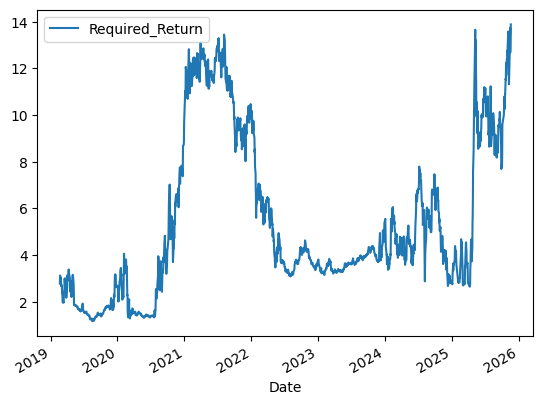

In [6]:

# 위 파일의 함수들을 복사해서 사용하거나
# 또는 파일을 그대로 실행

# API 키 입력
bok_key = "O6FJIBYZCWZF9ZFHL6F9"

# 날짜 설정
end_date = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')
start_date = "2014-01-01"

# 분석 실행
stock_code = '006910'

stock_result, market_result = analyze_stock_with_market(stock_code, start_date, end_date)

if stock_result is not None:
   display_analysis_summary(stock_result, market_result, stock_code)


treasury_data = get_korea_treasury_rates_ecos(start_date, end_date, bok_key)

if treasury_data is not None:
    display_treasury_summary(treasury_data)

if stock_result is not None:
        # 요구수익률 계산 (API 키 전달)
        result_df = calculate_required_return(stock_result, market_result, api_key= bok_key)


result_df[['Required_Return']].plot()

In [ ]:
import pymysql  # ← 맨 위 import 구역에 추가

# --------------------------------------------------------------------------------
# 1) 요구수익률 long-format → DB 저장 함수
# --------------------------------------------------------------------------------
def insert_required_return_to_db(long_df: pd.DataFrame,
                                 db_info: dict,
                                 table_name: str = "korea_required_return_result"):
    """
    date, ticker, indicator, value 형식의 long_format 데이터를
    MariaDB(investar)에 INSERT (ON DUPLICATE KEY UPDATE) 하는 함수
    """
    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4",
        autocommit=False
    )

    try:
        with conn.cursor() as cur:
            create_sql = f"""
            CREATE TABLE IF NOT EXISTS {table_name} (
                date DATE NOT NULL,
                ticker VARCHAR(20) NOT NULL,
                indicator VARCHAR(50) NOT NULL,
                value DOUBLE,
                PRIMARY KEY (date, ticker, indicator)
            ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
            """
            cur.execute(create_sql)

            insert_sql = f"""
            INSERT INTO {table_name} (date, ticker, indicator, value)
            VALUES (%s, %s, %s, %s)
            ON DUPLICATE KEY UPDATE
                value = VALUES(value);
            """

            data = []
            for _, row in long_df.iterrows():
                d = row["date"]
                if isinstance(d, pd.Timestamp):
                    d = d.strftime("%Y-%m-%d")
                data.append((
                    d,
                    row["ticker"],
                    row["indicator"],
                    float(row["value"]) if pd.notnull(row["value"]) else None
                ))

            cur.executemany(insert_sql, data)

        conn.commit()
        print(f"\n✓ DB 저장 완료: {len(long_df)} rows → {table_name}")

    except Exception as e:
        conn.rollback()
        print(f"\n✗ DB 저장 중 오류 발생: {e}")
    finally:
        conn.close()


# --------------------------------------------------------------------------------
# 2) KRX 상장사 중 10개 종목에 대해 요구수익률 계산 & DB 입력 테스트
# --------------------------------------------------------------------------------
def run_required_return_batch_test():
    # --- 설정값 ---
    bok_key = "O6FJIBYZCWZF9ZFHL6F9"   # 한국은행 ECOS API 키
    end_date = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')
    start_date = "2014-01-01"          # 베타 5년 계산을 고려해 충분히 길게
    min_required_start = pd.Timestamp("2019-01-01")  # 조건 1

    # DB 접속 정보
    db_info = {
        'host': get_db_host(),
        'port': 3307,
        'user': 'stox7412',
        'password': 'Apt106503!~',
        'database': 'investar'
    }

    # 1) 시장지수(KOSPI 지수) 데이터 한 번만 계산
    print("\n" + "=" * 80)
    print("KOSPI 지수 데이터 수집 및 분석")
    print("=" * 80)
    market_raw = fdr.DataReader('KS11', start_date, end_date)
    if market_raw is None or len(market_raw) == 0:
        print("✗ KOSPI 지수 데이터 수집 실패 - 종료")
        return

    market_analyzed = calculate_returns_and_volatility(market_raw)
    print(f"✓ KOSPI 데이터: {len(market_analyzed)}일")

    # 2) KRX 상장사 리스트 가져오기
    print("\n" + "=" * 80)
    print("KRX 상장사 리스트 수집")
    print("=" * 80)
    krx_list = fdr.StockListing('KRX')  # KOSPI + KOSDAQ + KONEX
    # 필요하면 아래처럼 시장 필터 가능
    # krx_list = krx_list[krx_list['Market'].isin(['KOSPI', 'KOSDAQ'])]

    tickers = krx_list['Code'].dropna().tolist()
    print(f"총 상장사 수: {len(tickers)}개")

    # 테스트용: 상위 10개만 사용
    test_tickers = tickers[:]
    print(f"테스트 대상 종목(10개): {test_tickers}")

    all_long_list = []

    # 3) 각 종목별로 요구수익률 계산
    for code in test_tickers:
        print("\n" + "-" * 80)
        print(f"[{code}] 종목 처리 시작")
        print("-" * 80)

        try:
            # (1) 주가 데이터 수집
            stock_raw = fdr.DataReader(code, start_date, end_date)

            if stock_raw is None or len(stock_raw) == 0:
                print(f"  → 주가 데이터 없음, 스킵")
                continue

            first_date = stock_raw.index.min()
            if first_date > min_required_start:
                print(f"  → 첫 데이터({first_date.date()})가 2019-01-01 이후 → 스킵")
                continue

            # (2) 수익률/변동성 계산
            stock_analyzed = calculate_returns_and_volatility(stock_raw)

            # (3) 베타 계산 (1Y, 3Y, 5Y), calculate_beta는 이미 정의됨
            stock_with_beta = calculate_beta(stock_analyzed, market_analyzed)

            # (4) 요구수익률 계산 (COE < Rf → Rf로 보정하는 버전)
            stock_rr = calculate_required_return(stock_with_beta, market_analyzed, api_key=bok_key)

            # (5) long-format 변환: date, ticker, indicator, value
            # 저장하고 싶은 지표들 리스트
            metric_cols = [
                # Rf / 시장수익률 / MRP / 요구수익률
                'Risk_Free_Rate',
                'Market_Return',
                'Market_Risk_Premium',
                'Required_Return',
                # 베타 (기간별)
                'Beta_1Y',
                'Beta_3Y',
                'Beta_5Y',
                # 주가의 기간별 누적수익률
                'Return_20D',
                'Return_60D',
                'Return_120D',
                'Return_252D',
                # 변동성 (원하면 같이 저장)
                'Volatility_20D',
                'Volatility_60D',
                'Volatility_120D',
                'Volatility_252D',
            ]

            # 실제 존재하는 컬럼만 사용 (방어 코드)
            metric_cols = [c for c in metric_cols if c in stock_rr.columns]

            wide = stock_rr[metric_cols].copy()

            # 인덱스를 date로 빼기
            wide = wide.reset_index()
            date_col = wide.columns[0]          # 보통 'Date' 또는 'index'
            wide = wide.rename(columns={date_col: 'date'})

            # wide → long: date, indicator, value
            long_df = wide.melt(
                id_vars=['date'],
                value_vars=metric_cols,
                var_name='indicator',
                value_name='value'
            )

            # ticker 붙이기
            long_df['ticker'] = code

            # 최종 컬럼 순서 정리
            long_df = long_df[['date', 'ticker', 'indicator', 'value']]

            all_long_list.append(long_df)

            print(f"  ✓ {code} 처리 완료 - {len(long_df)} rows")

        except Exception as e:
            # 조건 2: try-except로 에러가 나도 전체 루프는 계속
            print(f"  ✗ {code} 처리 중 오류 발생: {e}")
            continue

    # 4) 전체 long_format DF 생성 및 DB 저장
    if not all_long_list:
        print("\n✗ 처리된 데이터가 없어 DB 저장을 생략합니다.")
        return

    required_return_long = pd.concat(all_long_list, ignore_index=True)
    print("\n" + "=" * 80)
    print(f"최종 long_format 데이터 생성 완료 - 총 {len(required_return_long)} rows")
    print("=" * 80)

    # DB 입력
    insert_required_return_to_db(required_return_long, db_info)


# --------------------------------------------------------------------------------
# 3) 직접 실행 시 테스트용 엔트리 포인트
# --------------------------------------------------------------------------------
if __name__ == "__main__":
    run_required_return_batch_test()



KOSPI 지수 데이터 수집 및 분석
✓ KOSPI 데이터: 2915일

KRX 상장사 리스트 수집
총 상장사 수: 2881개
테스트 대상 종목(10개): ['005930', '000660', '373220', '207940', '005935', '005380', '329180', '034020', '012450', '105560', '000270', '068270', '042660', '035420', '402340', '055550', '028260', '015760', '009540', '196170', '032830', '267260', '051910', '012330', '035720', '086790', '005490', '006400', '010140', '000810', '010130', '064350', '096770', '298040', '034730', '138040', '316140', '003670', '011200', '267250', '033780', '024110', '000150', '009150', '066570', '247540', '010120', '018260', '006800', '003550', '352820', '030200', '086280', '259960', '042700', '017670', '086520', '047810', '003230', '323410', '326030', '010950', '000100', '010620', '272210', '298380', '047050', '007660', '443060', '079550', '071050', '005830', '278470', '003490', '005940', '277810', '087010', '039490', '090430', '161390', '005387', '016360', '377300', '000720', '141080', '032640', '000880', '028300', '180640', '021240', '029780', '